# Convert PSG config file to pd dataframe

In [18]:
from utils import PSG_input

temperature = PSG_input('Sorg20X').temperature
pressure = PSG_input('Sorg20X').pressure
df=PSG_input('Sorg20X').table

# Custom PSG config

Experimenting with different atmospheric compositions based on Sorg_20X config file to generate my own PSG config files. Copy-paste outputted rows for atmospheric structure and VMRs.

In [19]:
from utils import PSG_input
import matplotlib.pyplot as plt

df=PSG_input('Sorg20X').table
for i in range(100):
    row = f"<ATMOSPHERE-LAYER-{i+1}>"
    #values = [pressure[i],temperature[i],df['Altitude'][i],df['H2'][i],df['He'][i],df['H2O'][i],df['CH4'][i],df['C2H6'][i],df['CO2'][i],df['C2H2'][i],df['C2H4'][i],df['CO'][i],df['H2CO'][i],df['NH3'][i],df['SO2'][i],df['H2S'][i],df['SO'][i],df['CS2'][i],df['OCS'][i],df['DMS'][i],df['C2H6S2'][i]]
    #values = [df['Pressure'][i],df['Temperature'][i],df['Altitude'][i],0.799,0.15,0.0005,0.0005]
    #values = [df['Pressure'][i],df['Temperature'][i],df['Altitude'][i],df['H2'][i],df['He'][i],df['H2O'][i],df['CO2'][i],df['CO'][i],df['C2H6'][i],df['C2H4'][i],df['C2H2'][i],df['DMS'][i]]
    values = [pressure[i],temperature[i],df['Altitude'][i],df['H2'][i],df['He'][i],df['DMS'][i]]

    for x,value in enumerate(values):
        formatted = f"{value:.4E}"
        formatted = formatted[:-2] + formatted[-2:].zfill(2)  # Ensure 2-digit exponent
        if x==0:
            row+=f'{formatted}'
        else:
            row+=f',{formatted}'
    print(row)

<ATMOSPHERE-LAYER-1>1.0000E-08,2.1366E+02,0.0000E+00,7.2886E-01,1.5722E-01,2.4606E-06
<ATMOSPHERE-LAYER-2>1.2045E-08,2.1348E+02,7.7702E+00,7.2659E-01,1.5526E-01,2.5057E-06
<ATMOSPHERE-LAYER-3>1.4508E-08,2.1286E+02,1.5248E+01,7.2569E-01,1.5507E-01,2.4714E-06
<ATMOSPHERE-LAYER-4>1.7475E-08,2.1164E+02,2.2636E+01,7.2473E-01,1.5486E-01,2.4348E-06
<ATMOSPHERE-LAYER-5>2.1049E-08,2.0960E+02,2.9937E+01,7.2387E-01,1.5468E-01,2.3967E-06
<ATMOSPHERE-LAYER-6>2.5354E-08,2.0649E+02,3.7152E+01,7.2297E-01,1.5448E-01,2.3570E-06
<ATMOSPHERE-LAYER-7>3.0539E-08,2.0223E+02,4.4284E+01,7.2197E-01,1.5427E-01,2.3159E-06
<ATMOSPHERE-LAYER-8>3.6784E-08,1.9732E+02,5.1332E+01,7.2087E-01,1.5404E-01,2.2739E-06
<ATMOSPHERE-LAYER-9>4.4306E-08,1.9337E+02,5.8297E+01,7.1966E-01,1.5378E-01,2.2311E-06
<ATMOSPHERE-LAYER-10>5.3367E-08,1.9151E+02,6.5179E+01,7.1833E-01,1.5349E-01,2.1878E-06
<ATMOSPHERE-LAYER-11>6.4281E-08,1.9202E+02,7.1978E+01,7.1697E-01,1.5320E-01,2.1445E-06
<ATMOSPHERE-LAYER-12>7.7426E-08,1.9449E+02,7.8695E+0

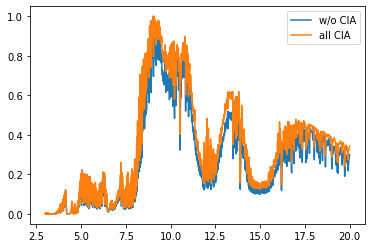

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

file=np.genfromtxt('./LIFE/Sorg20X/Sorg20X_spectrum_original.txt',skip_header=1,delimiter=' ')
wl=file[:,0]
fl=file[:,1]
fl/=np.max(fl)

# Identical PSG input except no CIA 
file=np.genfromtxt('./LIFE/Sorg20X/Sorg20X_woCIA_spectrum.txt',skip_header=1,delimiter=' ')
wl2=file[:,0]
fl2=file[:,1]
fl2/=np.max(fl2)

plt.plot(wl2,fl2,label='w/o CIA')
plt.plot(wl,fl,label='all CIA')
plt.legend()

# Convert LIFESim flux

Convert from photon flux to flux density (pRT flux units)
NOTE: currently not used in retrievals!! (pRT flux is converted to photon flux)

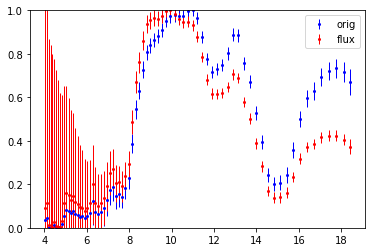

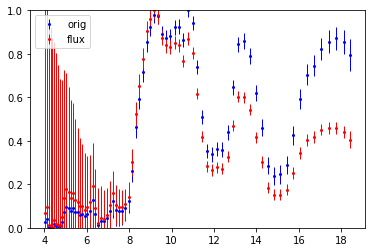

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def read_file(file):
    file=np.genfromtxt(f'LIFE/{file}',skip_header=1,delimiter='	')
    wl=file[:,0]
    fl=file[:,1]
    snr=file[:,2]
    err=fl/snr
    #err/=max(fl)
    #fl/=max(fl)
    return wl, fl, err

for n in [1,20]:
    n=int(n)
    wl_orig, fl_orig, err_orig = read_file(f'Sorg{n}X/k18b_{n}x_LIFEsim_DA_05032025.txt')
    plt.errorbar(wl_orig,fl_orig/max(fl_orig),yerr=err_orig/max(fl_orig),fmt='o',markersize=2,elinewidth=1,c='b',label='orig')
    plt.ylim(0,max(fl_orig/max(fl_orig)))
    # convert flux from [photons s^-1 m^-3] to [erg cm^{-2} s^{-1} cm^{-1}]
    fl = fl_orig/wl_orig
    err = err_orig/wl_orig
    maxflux = np.max(fl)
    #fl/=maxflux

    plt.errorbar(wl_orig,fl/max(fl),yerr=err/max(fl),fmt='o',markersize=2,elinewidth=1,c='r',label='flux')
    plt.legend()
    
    plt.show()

    spectrum=np.full(shape=(len(fl),3),fill_value=np.nan)
    spectrum[:,0]=wl_orig.flatten()
    spectrum[:,1]=fl_orig.flatten()
    spectrum[:,2]=err_orig.flatten()
    np.savetxt(f'LIFE/Sorg{n}X/Sorg{n}X_spectrum.txt',spectrum,delimiter=' ',header='wavelength(um) flux(photons/s1/m3) flux_error')

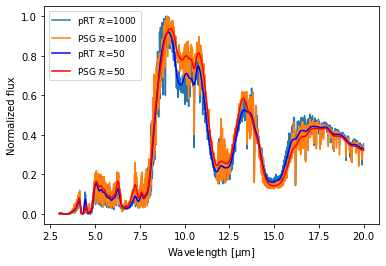

In [ ]:
import numpy as np
from astropy import units as u
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def convolve_to_resolution(in_wlen, in_flux, out_res, in_res=None):
        
    if isinstance(in_wlen, u.Quantity):
        in_wlen = in_wlen.to(u.nm).value
    if in_res is None:
        in_res = np.mean((in_wlen[:-1]/np.diff(in_wlen)))
    # delta lambda of resolution element is FWHM of the LSF's standard deviation:
    sigma_LSF = np.sqrt(1./out_res**2-1./in_res**2)/(2.*np.sqrt(2.*np.log(2.)))
    spacing = np.mean(2.*np.diff(in_wlen)/(in_wlen[1:]+in_wlen[:-1]))

    # Calculate the sigma to be used in the gauss filter in pixels
    sigma_LSF_gauss_filter = sigma_LSF/spacing
    out_flux = np.tile(np.nan, in_flux.shape)
    nans = np.isnan(in_flux)
    out_flux[~nans] = gaussian_filter(in_flux[~nans], sigma = sigma_LSF_gauss_filter, mode = 'reflect')

    return out_flux

def read_file(file):
    file=np.genfromtxt(f'LIFE/Sorg20X/{file}.txt',skip_header=1,delimiter=' ')
    wl=file[:,0]
    fl=file[:,1]
    fl/=np.max(fl)
    return wl, fl

wl1, fl1 = read_file('Sorg20X_spectrum')
wl2, fl2 = read_file('Sorg20X_spectrum_original')
wl3, fl3 = read_file('Sorg20X_pRT_spectrum')
fl4 = convolve_to_resolution(wl3, fl3, 50)
fl5 = convolve_to_resolution(wl2, fl2, 50)

plt.plot(wl3,fl3,label='pRT $\mathcal{R}$=1000',color='tab:blue')
plt.plot(wl2,fl2,label='PSG $\mathcal{R}$=1000',color='tab:orange')
plt.plot(wl3,fl4,label='pRT $\mathcal{R}$=50',color='b')
plt.plot(wl2,fl5,label='PSG $\mathcal{R}$=50',color='r')
# CANNOT compare to LIFESim spectrum (different units - photon flux)
#plt.plot(wl1,fl1,label='LIFESim $\mathcal{R}$=50',color='limegreen')

plt.legend(loc='upper left',fontsize=9)
plt.xlabel('Wavelength [$\mathrm{\mu}$m]')
plt.ylabel('Normalized flux')
plt.savefig('figures/Sorg20X_spectra.jpg',dpi=200)